# Quantum Metric Learning

This notebook demonstrates supervised **quantum metric learning** using a
trainable embedding circuit.

The embedding parameters are optimised using a **contrastive loss**:

- same-class samples are pulled closer together
- different-class samples are pushed apart

Classification is performed using a **nearest-centroid rule** in the learned
quantum feature space.

The notebook is a thin client that calls into the `qml` package.

In [1]:
from qml.metric_learning import run_quantum_metric_learner

[metric_learning] step=0001 loss=0.427937
[metric_learning] step=0010 loss=0.305071
[metric_learning] step=0020 loss=0.298624
[metric_learning] step=0030 loss=0.255549
[metric_learning] step=0040 loss=0.286283
[metric_learning] step=0050 loss=0.260128


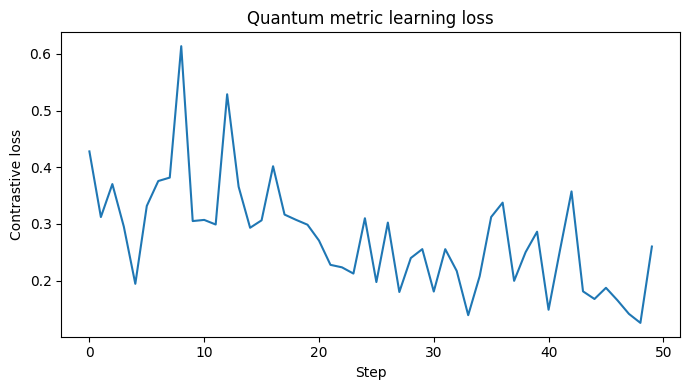

Train accuracy: 0.6222222222222222
Test accuracy: 0.6666666666666666
Final loss: 0.26012762849532656


In [ ]:
result = run_quantum_metric_learner(
    dataset="moons",
    samples=120,
    layers=2,
    steps=50,
    stepsize=0.05,
    margin=0.5,
    pairs_per_step=32,
    seed=123,
    plot=True,
)

print("Train accuracy:", result.train_accuracy)
print("Test accuracy:", result.test_accuracy)
print("Final loss:", result.loss_history[-1])

In [3]:
# Inspect embedding outputs

print("Train embedding shape:", result.train_embeddings.shape)
print("Test embedding shape:", result.test_embeddings.shape)

Train embedding shape: (90, 2)
Test embedding shape: (30, 2)


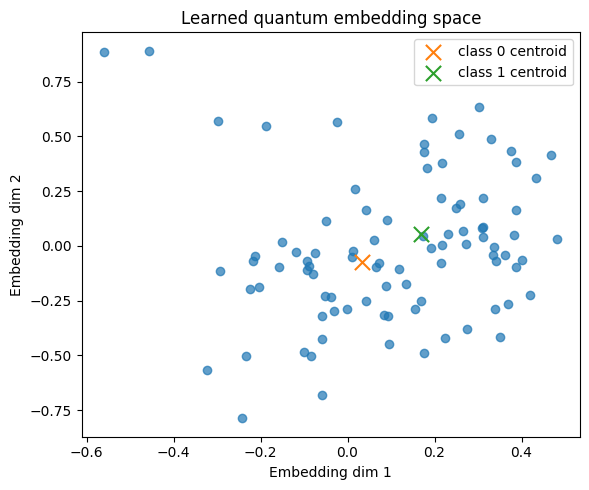

In [4]:
# Visualise learned embedding space (2D)

import matplotlib.pyplot as plt

train_embeddings = result.train_embeddings
centroids = result.train_centroids

plt.figure(figsize=(6, 5))

plt.scatter(
    train_embeddings[:, 0],
    train_embeddings[:, 1],
    alpha=0.7,
)

for cls, centroid in centroids.items():
    plt.scatter(
        centroid[0],
        centroid[1],
        marker="x",
        s=120,
        label=f"class {cls} centroid",
    )

plt.title("Learned quantum embedding space")
plt.xlabel("Embedding dim 1")
plt.ylabel("Embedding dim 2")
plt.legend()
plt.tight_layout()

plt.show()

In [5]:
# Quick hyperparameter variation

result_small = run_quantum_metric_learner(
    dataset="moons",
    samples=120,
    layers=1,
    steps=30,
    pairs_per_step=16,
    seed=123,
)

print("layers=1 test accuracy:", result_small.test_accuracy)

[metric_learning] step=0001 loss=0.087691
[metric_learning] step=0010 loss=0.225662
[metric_learning] step=0020 loss=0.134055
[metric_learning] step=0030 loss=0.130827
layers=1 test accuracy: 0.6333333333333333


In [6]:
# Compare dataset choices

for dataset in ["moons", "circles", "blobs"]:

    res = run_quantum_metric_learner(
        dataset=dataset,
        samples=120,
        layers=2,
        steps=40,
        seed=123,
    )

    print()
    print(dataset)
    print("  train accuracy:", res.train_accuracy)
    print("  test accuracy:", res.test_accuracy)

[metric_learning] step=0001 loss=0.427937
[metric_learning] step=0010 loss=0.305071
[metric_learning] step=0020 loss=0.298624
[metric_learning] step=0030 loss=0.255549
[metric_learning] step=0040 loss=0.286283

moons
  train accuracy: 0.5777777777777777
  test accuracy: 0.6
[metric_learning] step=0001 loss=0.356441
[metric_learning] step=0010 loss=0.428865
[metric_learning] step=0020 loss=0.303805
[metric_learning] step=0030 loss=0.204626
[metric_learning] step=0040 loss=0.247740

circles
  train accuracy: 0.7555555555555555
  test accuracy: 0.7
[metric_learning] step=0001 loss=0.140471
[metric_learning] step=0010 loss=0.056122
[metric_learning] step=0020 loss=0.094982
[metric_learning] step=0030 loss=0.065302
[metric_learning] step=0040 loss=0.064415

blobs
  train accuracy: 0.8777777777777778
  test accuracy: 0.8
